In [1]:
import os, sys
sys.path.append("../")
from pymoods.utils.mocodo import *

In [2]:
DATA_DIR = "../../data"
JLD2_FILEDIR = os.path.join(DATA_DIR, "DataExchangeMilan_Project2.2a/solution")
OUTPUT_DIR = os.path.join(DATA_DIR, "DataExchangeMilan_Project2.2a/processed")

## Example Scenario

In [3]:
sel_usecase = "CCD18-3"
sel_loc = "COTWDPGE"

data_file = f"{JLD2_FILEDIR}/{sel_usecase}/{sel_loc}_Sol.jld2"
df_realigned, scaler_dict = read_jld2_solution_file_as_df(data_file)

kerntree_file = f'{JLD2_FILEDIR}/{sel_usecase}/ScenTree_{sel_loc}.jld2'
kerntree = read_kerntree(kerntree_file)

In [4]:
rt_scenario = 22
scenario_example = df_realigned.loc[rt_scenario]
scenario_example

,ChS,DisS,SCS,WPQ,WSQ,kBS,kWS,lam_DAQ,lam_RT,pRBDS,...,pRWDS,pRWUS,pWDSQ,pWRS,pWSQ,v1,v2,WS,pWDS,pWS
time,,,,,,,,,,,,,,,,,,,,,
0,0.000553,0.000186,108.601846,0.000000,1.631244,2.998829,0.000000,111068.493725,113957.371061,2.261617,...,0.000000,0.000000,755.469618,-755.468027,0.000000,482.336643,482.336638,1.631244,755.469618,0.000000
1,0.000677,0.000174,108.601952,0.000000,1.631244,2.998855,0.000000,111068.493725,111151.766882,2.261636,...,0.000000,0.000000,755.469618,-755.468164,0.000000,482.334949,482.334945,1.631244,755.469618,0.000000
2,0.000871,0.000163,108.602106,0.000000,1.631244,2.998880,0.000000,111068.493725,108346.162703,2.261655,...,0.000000,0.000000,755.469618,-755.468369,0.000000,482.333310,482.333306,1.631244,755.469618,0.000000
3,0.001219,0.000154,108.602341,0.000000,1.631244,2.998904,0.000000,111068.493725,105540.558524,2.261673,...,0.000000,0.000000,755.469618,-755.468728,0.000000,482.331612,482.331607,1.631244,755.469618,0.000000
4,0.002165,0.000144,108.602794,0.000000,1.656754,2.998926,0.000000,100218.649657,102734.954344,2.261690,...,0.000000,0.000000,726.811284,-726.811351,0.000000,482.323881,482.323877,1.656754,726.811284,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,0.000217,0.000443,0.000798,691.461246,7.663843,2.999346,0.764055,119888.365000,121907.254933,2.262007,...,0.576225,5.668652,1065.083580,-383.599958,685.702067,509.995498,506.857120,7.663843,1065.083580,685.702067
92,0.000237,0.000392,0.000744,596.210890,7.309430,2.999225,0.658807,111531.770208,119256.779727,2.261915,...,0.496850,4.887796,969.886566,-381.777200,591.245455,509.993621,507.287550,7.309430,969.886566,591.245455
93,0.000211,0.000501,0.000654,596.210890,7.309430,2.999282,0.658807,111531.770208,120581.631893,2.261958,...,0.496850,4.887796,969.886566,-381.777062,591.245455,509.993691,507.287620,7.309430,969.886566,591.245455


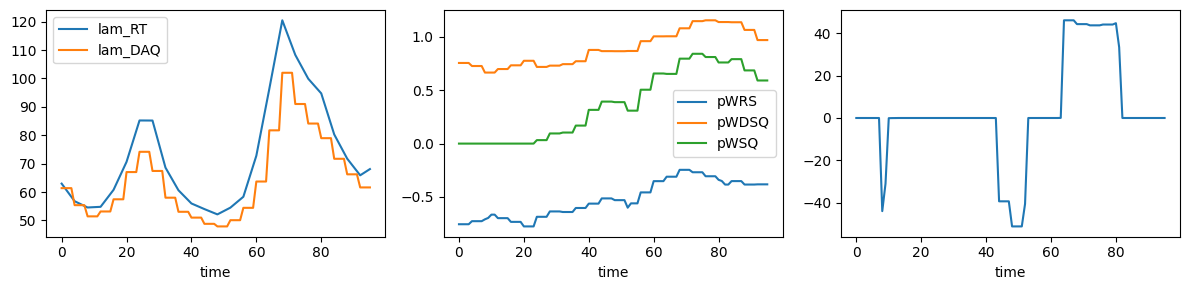

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
(scenario_example[["lam_RT", "lam_DAQ"]] / scaler_dict['PowerBase']).plot(ax=ax[0])
(scenario_example[["pWRS", "pWDSQ", "pWSQ"]] / 1000).plot(ax=ax[1])
(scenario_example["DisS"]-scenario_example["ChS"]).plot(ax=ax[2])
# It should be DisS - ChS

fig.tight_layout()

## Data Processing

In [6]:
States = interpolate_states(kerntree["state"])

In [7]:
kerntree["state"].shape

(421, 24)

In [8]:
# solution
CS = 1991.00
SZ = 54.30

# default values
CabLength = 545.060*1e3
PowerBase = scaler_dict['PowerBase']

CabC = 2*0.3476*0.3351*1e6/525/1e3*CabLength*PowerBase # Cable material cost $/p.u
lam_ESS = 1.27009e6*PowerBase

CabFixC = 2*0.3476*0.0001*CabLength # Cable fixed cost
CabIntC = 2.7*1e6/16000*CabLength; # Cable installation cos

TaxCredit = 0.3 # 30% tax credit for capital cost

In [9]:
S1 = scaler_dict["S1"]
S2 = scaler_dict["S2"] # scenario picker
S21 = scaler_dict["S21"]

In [10]:
# probability sets
P1 = dict()
P2 = dict()
P21 = dict()
for s in S1:
    P1[s] = kerntree["probability"][s-1]

for s in S2:
    P2[s] = kerntree["probability"][s-1]*kerntree["probability"][kerntree["parent"][s-1]-1]
    P21[s] = kerntree["probability"][s]

In [11]:
lam_DA = dict()
lam_RT = dict()
lam_ReU = dict()
lam_ReD = dict()
WS = dict()
WP = dict()

for s in S1:
    lam_DA[s] = kerntree["state"][s-1, :] # DA price scenarios

for s in S2:
    WS[s] = kerntree["state"][s-1, :]
    # WP[s] = Turbine_PC.(WS[s], (breakpts,), (coefs,))/RatedPower*SW
    col = kerntree["children"][s][0]
    lam_RT[s] = States[col-1, :] # RT price scenarios
    col = kerntree["children"][col][0]
    lam_ReU[s] = States[col-1, :] # Up reserve price scenarios
    col = kerntree["children"][col][0]
    lam_ReD[s] = States[col-1, :] # Down reserve price scenarios


In [12]:
lam_ReD[s]

array([ 1.30846242e+00,  1.08931583e+00,  8.70169247e-01,  6.51022660e-01,
        4.31876074e-01,  4.31876074e-01,  4.31876074e-01,  4.31876074e-01,
        4.31876074e-01,  4.31876074e-01,  4.31876075e-01,  4.31876075e-01,
        4.31876076e-01,  4.31876077e-01,  4.31876078e-01,  4.31876079e-01,
        4.31876080e-01,  1.40250724e+00,  2.37313840e+00,  3.34376956e+00,
        4.31440071e+00,  3.53561322e+00,  2.75682572e+00,  1.97803822e+00,
        1.19925072e+00,  8.99438040e-01,  5.99625362e-01,  2.99812683e-01,
        4.88230582e-09,  3.27101172e-09,  1.65971761e-09,  4.84235099e-11,
       -1.56287059e-09, -2.19753805e-09, -2.83220551e-09, -3.46687296e-09,
       -4.10154042e-09, -3.04127083e-09, -1.98100123e-09, -9.20731637e-10,
        1.39537957e-10, -3.63746817e-10, -8.67031592e-10, -1.37031637e-09,
       -1.87360114e-09, -6.98125599e-10,  4.77349943e-10,  1.65282549e-09,
        2.82830103e-09,  1.40384161e-09, -2.06178164e-11, -1.44507724e-09,
       -2.86953666e-09, -

In [13]:
# objective values
obj1 = (1-TaxCredit)*CabC*CS
obj2 = (1-TaxCredit)*lam_ESS*SZ

# sum(lam_DA[s][t]*pWD[t,s]*P1[s] for t in T1, s in S1)
# DA revenue $k
dt_scenario = kerntree["parent"][rt_scenario-1]
DAR = lam_DA[dt_scenario] *\
        df_realigned.loc[kerntree["children"][dt_scenario][0]]["pWDSQ"][::4] *\
        P1[dt_scenario] / 1e3

# lam_RT[s][t]*pWR[t,s]*P2[s]
# RT revenue $k
RTR = lam_RT[rt_scenario] *\
        df_realigned.loc[rt_scenario]["pWRS"] *\
        P2[rt_scenario] / 4 / 1e3

# lam_ReU[s][t]*(pRWU[t,s]+pRBU[t,s])*P2[s]
# up reserve revenue $k
REUR = lam_ReU[rt_scenario] *\
        (df_realigned.loc[rt_scenario]["pRWUS"] + df_realigned.loc[rt_scenario]["pRBUS"]) *\
        P2[rt_scenario] / 4 / 1e3

# lam_ReD[s][t]*(pRWD[t,s]+pRBD[t,s])*P2[s]
# down reserve revenue $k
REDR = lam_ReD[rt_scenario] *\
        (df_realigned.loc[rt_scenario]["pRWDS"] + df_realigned.loc[rt_scenario]["pRBDS"]) *\
        P2[rt_scenario] / 4 / 1e3

In [14]:
P2[rt_scenario]

np.float64(0.01438)

In [15]:
# sum(lam_DA[s][t]*pWD[t,s]*P1[s] for t in T1, s in S1)
# DA revenue $k
dar_dict = {}
for dt_scenario in S1:
    dar_dict[dt_scenario] = lam_DA[dt_scenario] *\
            df_realigned.loc[kerntree["children"][dt_scenario][0]]["pWDSQ"][::4] *\
            P1[dt_scenario] / 1e3
dar_frame = pd.DataFrame(pd.DataFrame(dar_dict).stack().swaplevel(0, 1).sort_index())
dar_frame.index.names = ['sim', 'time']
dar_frame.columns = ['dar']

# lam_RT[s][t]*pWR[t,s]*P2[s]
# RT revenue $k
rtr_dict = {}
for rt_scenario in S2:
    rtr_dict[rt_scenario] = lam_RT[rt_scenario] *\
            df_realigned.loc[rt_scenario]["pWRS"] *\
            P2[rt_scenario] / 4 / 1e3
rtr_frame = pd.DataFrame(rtr_dict).stack().swaplevel(0, 1).sort_index()
rtr_frame.index.names = ['sim', 'time']

# lam_ReU[s][t]*(pRWU[t,s]+pRBU[t,s])*P2[s]
# up reserve revenue $k
reur_dict = {}
for rt_scenario in S2:
    reur_dict[rt_scenario] = lam_ReU[rt_scenario] *\
        (df_realigned.loc[rt_scenario]["pRWUS"] + df_realigned.loc[rt_scenario]["pRBUS"]) *\
        P2[rt_scenario] / 4 / 1e3
reur_frame = pd.DataFrame(reur_dict).stack().swaplevel(0, 1).sort_index()
reur_frame.index.names = ['sim', 'time']

# lam_ReD[s][t]*(pRWD[t,s]+pRBD[t,s])*P2[s]
# down reserve revenue $k
redr_dict = {}
for rt_scenario in S2:
    redr_dict[rt_scenario] = lam_ReD[rt_scenario] *\
        (df_realigned.loc[rt_scenario]["pRWDS"] + df_realigned.loc[rt_scenario]["pRBDS"]) *\
        P2[rt_scenario] / 4 / 1e3
redr_frame = pd.DataFrame(redr_dict).stack().swaplevel(0, 1).sort_index()
redr_frame.index.names = ['sim', 'time']

In [16]:
rt_frame = pd.concat([rtr_frame, reur_frame, redr_frame], axis=1)
rt_frame.columns = ["rtr", "reur", "redr"]
rt_frame

rtr          reur          redr
sim time                                      
22  0    -0.170993  3.654738e-05  4.778614e-06
    1    -0.166783  3.867666e-05  3.585784e-06
    2    -0.162574  4.080595e-05  2.392933e-06
    3    -0.158364  4.293527e-05  1.200062e-06
    4    -0.148307  4.506461e-05  7.171923e-09
...            ...           ...           ...
121 91   -0.000421  7.177281e-07  1.405201e-07
    92   -0.000049  9.949528e-15  1.202954e-07
    93   -0.000049  1.406091e-14  5.339834e-08
    94   -0.000049  4.661799e-16 -3.920108e-11
    95   -0.000049  5.901654e-16 -1.377935e-09

[9600 rows x 3 columns]

In [17]:
rt_frame.sum()

rtr     19.086819
reur     1.425382
redr     0.163748
dtype: float64

In [18]:
dar_frame

dar
sim time          
2   0     1.837651
    4     1.595237
    8     1.356522
    12    1.471451
    16    1.669621
...            ...
21  76    0.080989
    80    0.176648
    84    0.098399
    88    0.037869
    92    0.004004

[480 rows x 1 columns]

<Axes: xlabel='time'>

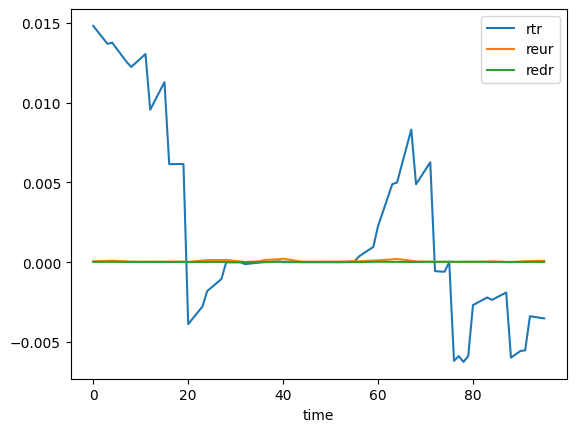

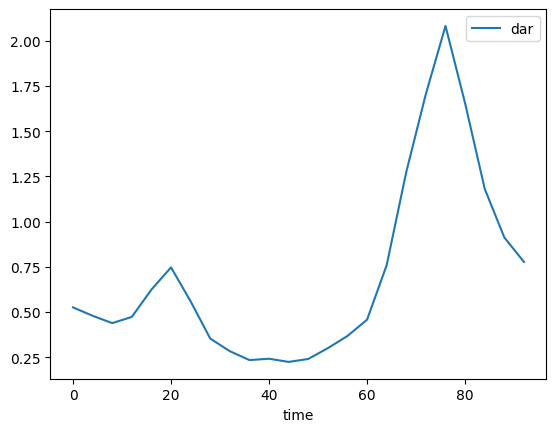

In [19]:
rt_frame.loc[101].plot()
dar_frame.loc[17].plot()